# <center> Визуализация данных в Pandas

Визуализация данных — важный компонент любого исследования в области анализа данных. Наглядные и информационно адекватые графики и диаграммы часто бывают более понятны, чем многословное объяснение.

Визуализация данных - это мощный способ улавливать зависимости и представлять информацию, полученную на основе данных. Среди средств, доступных в Python, имеется множество инструментов визуализации данных. В рамках этого занятия изучается построение графиков и диаграмм с помощью пакета **Pandas**.

В теме 1 рассматривался инструментарий библиотеки **Matplotlib**; было изучено построение линейных графиков, диаграммы рассеяния и гистограммы.
    
Одним из достоинств **Pandas** является возможность построения этих же самых графиков без явного импортирования **Matplotlib**, причем организовать такое построение можно разными способами. При этом стоит отметить, что **Pandas** "под капотом" использует инструментарий **Matplotlib**, хотя нигде в коде не требуется это указывать.

Подключим библиотеки Panads и NumPy:

In [1]:
import pandas as pd
import numpy as np

## <center> Простейшие графики

### Линейный график
  
В учебном блокноте, посвященном знакомству с **Matplotlib**, было показано построение простейшего линейного графика:

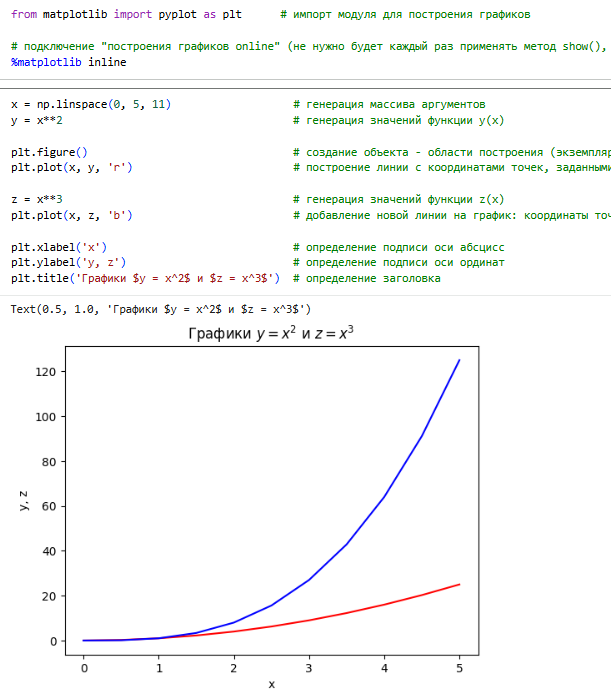

Обратите внимание на необходимость подключения модуля Pyplot при работе с инструментарием Matplotlib напрямую.

В текущем блокноте этот модуль не подключен, однако, тот же самый результат может быть получен через инструментарий Pandas (который уже самостоятельно будет обращаться к нужным объектам Matplotlib)

     $y = x^2$  $z = x^3$
0.0       0.00      0.000
0.5       0.25      0.125
1.0       1.00      1.000
1.5       2.25      3.375
2.0       4.00      8.000
2.5       6.25     15.625
3.0       9.00     27.000
3.5      12.25     42.875
4.0      16.00     64.000
4.5      20.25     91.125
5.0      25.00    125.000


<Axes: >

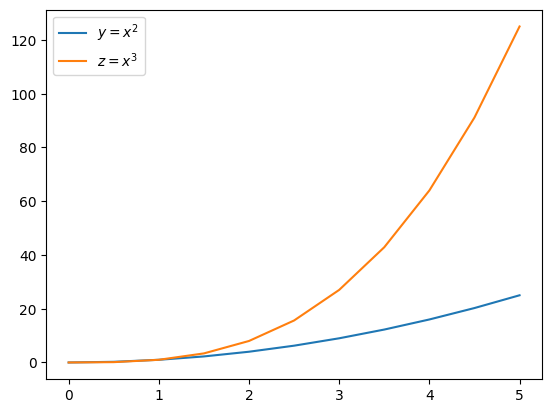

In [2]:
x = np.linspace(0, 5, 11)                    # генерация массива аргументов функции (ось Х)
y = x**2                                     # генерация значений функции y(x)
z = x**3                                     # генерация значений функции z(x)

df = pd.DataFrame({'$y = x^2$': y,           # формирование фрейма (через словарь) из двух столбцов y и z,
                   '$z = x^3$': z}, index=x) # у которых индексом является x

print(df)                                    # вывод фрейма в виде таблицы
df.plot()                                    # вывод фрейма в виде графика


В библиотеке Pandas вся работа по построению и оформлению графиков и диаграмм реализуется через универсальный метод <b>plot()</b>. Поскольку эта библиотека ориентирована на работу с фреймами данных (или сериями), то метод <b>plot()</b> применяется именно к фреймам (в примере выше это <code>df.plot()</code> - применение метода <b>plot()</b> к фрейму **df**).

Фрейм должен быть предварительно сформирован. В примере выше фрейм **df** построен на базе трёх numpy-массивов, два из которых (**y** и **z**) представляют визуализируемые данные (столбцы фрейма), а один (**x**) - индекс этих данных (значения по оси абсцисс).

При обращении к методу <b>plot()</b> элементы оформления графика явно описаны не были, поэтому метод использовал настройки по умолчанию: в легенде отобразились имена столбцов фрейма **df** - как имена отдельных линий.

Обратите внимание на работу чудесного символа $ в названиях серий.

### Элементы настройки линейного графика
Использование фрейма данных для хранения значений математических функций встречается крайне редко (зачем хранить эти значения, если их легко можно вычислить). В предыдущем примере это было сделано в чисто иллюстративных целях для сопоставления с результатами, полученными ранее в теме 1.

При работе с реальными данными визуализация в форме линейного графика обычно применяется для представления временных рядов.
    
В качестве иллюстративного примера временного ряда возьмём игрушечный набор из 14 целочисленных значений. Поскольку это одномерный набор, то естественным его представлением будет Series (серия данных).

По умолчанию нумерация элементов серии начинается с нуля. Сформируем список индексов, начиная с 1, и применим к серии метод <b>plot()</b>

<Axes: >

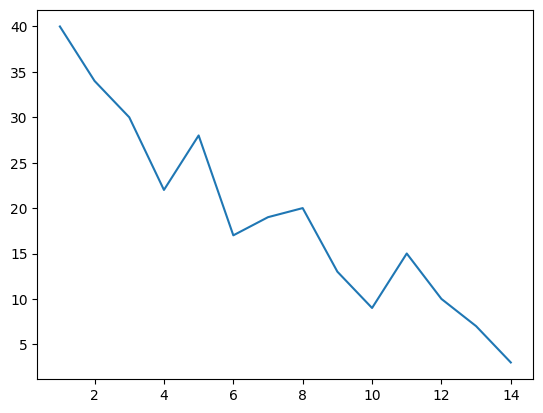

In [3]:
x = np.linspace(1, 14, 14)
a = pd.Series([40, 34, 30, 22, 28, 17, 19, 20, 13, 9, 15, 10, 7, 3], index = x)
a.plot()

Можно представить себе, что на графике отображено изменение температуры воздуха в Тюмени в первые две недели февраля; индекс соответствует номеру дня в феврале.

Для добавления к оформлению графика новых элементов или настройки существующих, следует использовать параметры метода **plot()**.
    
Например:

<Axes: title={'center': 'Температура в Тюмени в феврале'}>

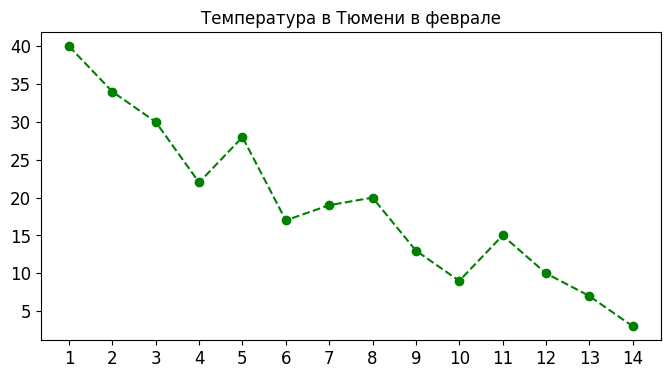

In [4]:
a.plot(figsize=(8, 4), color='green', style='o--', title = 'Температура в Тюмени в феврале', fontsize=12, xticks=x)

В настройках были изменены:
- размер изображения: (<code>figsize=(8, 4)</code>),
- цвет линии (зеленый): (<code>color='green'</code>),
- стиль линии (пунктир с круглыми маркерами точек): (<code>style='o--'</code>),
- текст заголовка графика: (<code>title = 'Температура в Тюмени в феврале'</code>)
- размер шрифта для меток на осях: (<code>fontsize=12</code>).
- шаг меток по оси абцисс (догадайтесь сами или прочитайте в следующем абзаце).

Обратите внимание: настройки цвета линии и размера шрифта будут действовать и для следующих графиков, пока параметрам не будут заданы новые значения.

Метод **plot()** имеет достаточно много параметров. Некоторые из них уже рассмотрены раньше или будут рассмотрим позднее.
Некоторые парметры представлены в списке ниже:
- **style** : строка, определяющая стиль графика (например, o--);
- **alpha** : степень прозрачности заполнения графика (от 0 до 1);
- **logy** : использовать ли логарифмический масштаб по оси y;
- **use_index** : использовать ли объект индекс для меток оси;
- **xticks** : значения для меток оси абсцисс;
- **yticks** : значения для меток оси ординат;
- **xlim** : границы по оси абсцисс (например, [0, 10]);
- **ylim** : границы по оси ординат;
- **grid** : отображать ли сетку по осям (по умолчанию False);
- **subplots** : располагать ли график для каждой серии в отдельном окне (по умолчанию False).

Описание всех параметров можно найти в [документации](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html) метода.

Временные данные часто содержат не один показатель (как в примере выше - температура воздуха в Тюмени), а несколько. В таком случае для хранения набора данных одной серии уже недостаточно, и нужно использовать фрейм данных.

Продолжим рассмотрение примера выше: создадим фрейм **Т**, в котором, кроме тюменской температуры, будут храниться значения температуры в двух других городах: Красноярске и Салехарде.

Настройки оформления графика оставим по умолчанию (метод **plot()** практически без параметров)

<Axes: title={'center': 'Температура в городах'}>

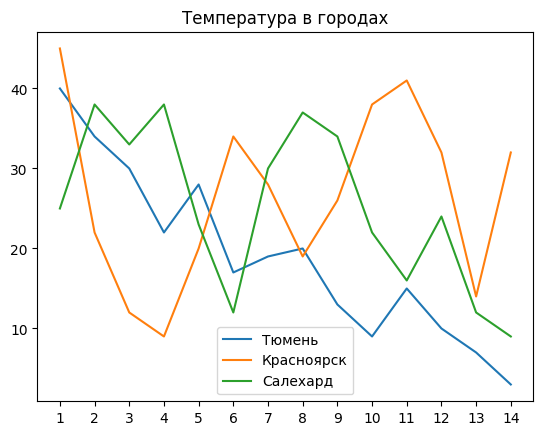

In [5]:
b = pd.Series([45, 22, 12, 9, 20, 34, 28, 19, 26, 38, 41, 32, 14, 32], index = x)  # создание двух дополнительных серий температур
c = pd.Series([25, 38, 33, 38, 23, 12, 30, 37, 34, 22, 16, 24, 12, 9], index = x)
T = pd.DataFrame({'Тюмень':a, 'Красноярск': b, 'Салехард': c})                     # создание фрейма из всех трех серий (через словарь)
T.plot(title = 'Температура в городах', xticks=x)

Выглядит несколько хаотично, но таковы были исходные данные.

Внимательный студент, конечно, заметил, что с данными созданного выше фрейма **Т** "что-то не так": февральская температура в сибирских городах выглядит довольно фантастичной. Она, конечно, должна быть отрицательной (или хотя бы близкой к нулю).

Хотя для тестирования фрагментов программного кода часто используются не настоящие (сгенерированные) данные, важно, чтобы эти данные были максимально похожими на реальные. В рассматриваемом примере эта проблема решается легко: достаточно изменить знак у всех значений фрейма **Т**.

Возможности Pandas позволяют очень легко внести исправление и отрисовать более правдоподобный график для нового фрейма:


<Axes: title={'center': 'Температура в городах'}>

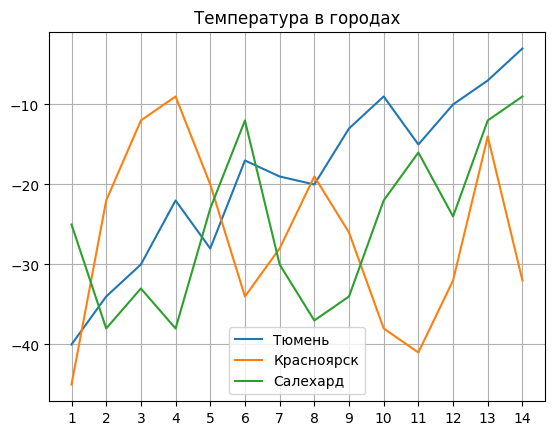

In [6]:
Term=-T
Term.plot(title = 'Температура в городах', xticks=x, grid=True)

### Виды графиков (диаграмм), доступные в Pandas
  
Среди необязательных параметров метода **plot()** имеется параметр **kind**, который определяет, какой тип графика будет создан. Значением параметра может быть одна из следующих строк:

- «**line**» – линейный график;
- «**area**» – область под графиком;
- «**bar**» – вертикальная столбчатая диаграмма;
- «**barh**» – горизонтальные столбчатые диаграммы;
- «**box**» – коробчатая диаграмма;
- «**hist**» – гистограмма;
- «**kde**» – оценка плотности ядра (или «**density**»);
- «**pie**» – круговая диаграмма;
- «**scatter**» – диаграмма рассеяния;
- «**hexbin**» – диаграмма рассеяния с шетиугольными ячейками.
    
Как показано в предыдущих примерах, по умолчанию строится линейный график.
    
Для построения графика другого типа можно использовать два способа определения типа графика (диаграммы).
    
1. Через строковое значение параметра **kind**:
    
<code>Dataframe.plot(kind = '<вид желаемого графика>', ...)</code>
          
2. Указание значения **kind** через обращение к одноименному методу, уточняющему работу метода **plot** .     
<code>Dataframe.plot.<вид желаемого графика>(...)</code>

В некоторых редакторах кода, поддерживающих режим "подсказки", при наборе идентификатора среда сама предложит допустимые в данном случае названия (по первым введённым символам)

### Графики типа AREA - область под линией графика.
   
Область под графиком (Area plot, зонная диаграмма) отличается от линейного графика заливкой пространства под графиком.

Например, для одиночного графика (используется первый вариант указания типа графика):

<Axes: >

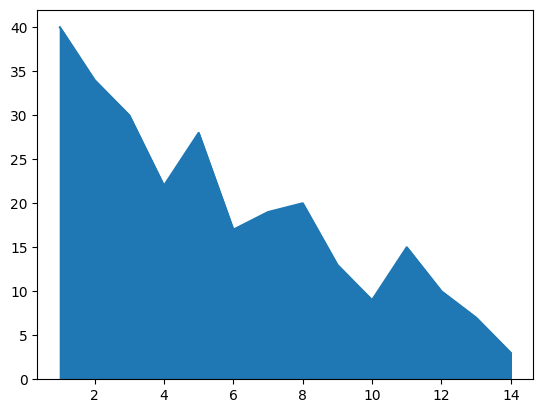

In [7]:
a.plot(kind = 'area')          # использована созданная ранее серия

Если для простроения диаграммы используется несколько серий фрейма данных, то закрашиваются пространства между графиками (для иллюстрации использован второй вариант указания типа графика):

<Axes: >

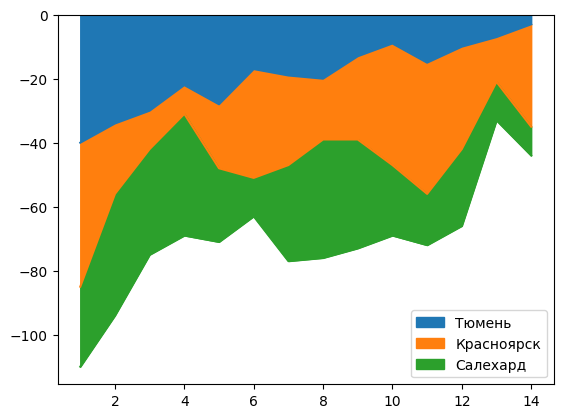

In [8]:
Term.plot.area()              # использован созданный ранее фрейм из трех серий

Эта диаграмма совсем не похожа на представление этих же данных в виде линейных графиков.

В чём отличие в построении графиков этих типов и какой смысл имеют закрашеные области между графиками? Постарайтесь найти ответ на этот вопрос самостоятельно (изучая документацию или подумайте сами, проанализировав вид графиков).

### Круговая диаграмма PIE
Представим, что созданный ранее игрушечный фрейм данных **T** представляет не значение температуры в городах, а число ДТП в этих городах в первые дни февраля. Создадим клон датафрейма **T** с именем **DTP**:

In [9]:
DTP=T.copy()
DTP.head()

,Тюмень,Красноярск,Салехард
1.0,40,45,25
2.0,34,22,38
3.0,30,12,33
4.0,22,9,38
5.0,28,20,23


Для наглядного представления доли числа ДТП, случившихся в каждый отдельный день в Тюмени (в общем количестве ДТП по Тюмени за весь период), подойдёт круговая диаграмма:

<Axes: ylabel='Тюмень'>

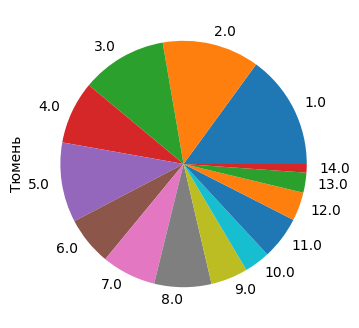

In [10]:
DTP['Тюмень'].plot.pie(figsize=(4, 4))

Попробуем повысить информативность диаграммы.

Метки на диаграмме с параметрами по умолчанию являются индексами элементов серии (столбца фрейма, выбранного для построения диаграммы). Они были сгенерированы с помощью массива NumPy, поэтому, по умолчанию, являются вещественными числами.

Преобразуем их в целые:

In [11]:
DTP.index=DTP.index.astype('int')
DTP.head()

,Тюмень,Красноярск,Салехард
1,40,45,25
2,34,22,38
3,30,12,33
4,22,9,38
5,28,20,23


Добавим заголовок диаграммы и отобразим в секторах их размеры в процентах

<Axes: title={'center': 'Процент ДТП по дням февраля'}, ylabel='Тюмень'>

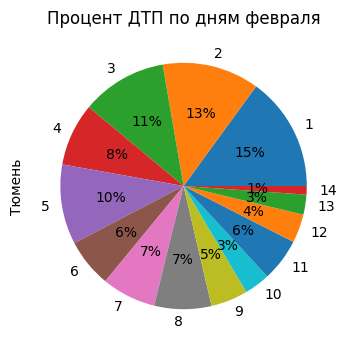

In [12]:
DTP['Тюмень'].plot(kind = 'pie', figsize=(4, 4), autopct='%1.0f%%', title='Процент ДТП по дням февраля')

Если команду построения графика завершить символом ";", то на консоль не будет выведена служебная информация:

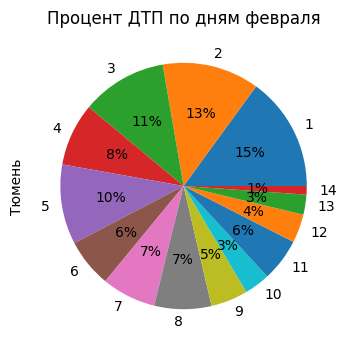

In [13]:
DTP['Тюмень'].plot(kind = 'pie', figsize=(4, 4), autopct='%1.0f%%', title='Процент ДТП по дням февраля');

Чтобы увидеть полную картину по всем трём городам, построим круговые диаграммы по каждому городу как подграфики одного изображения.
Уберём легенду, которая, предположительно будет в данном случае лишней (или не будет - проверьте).

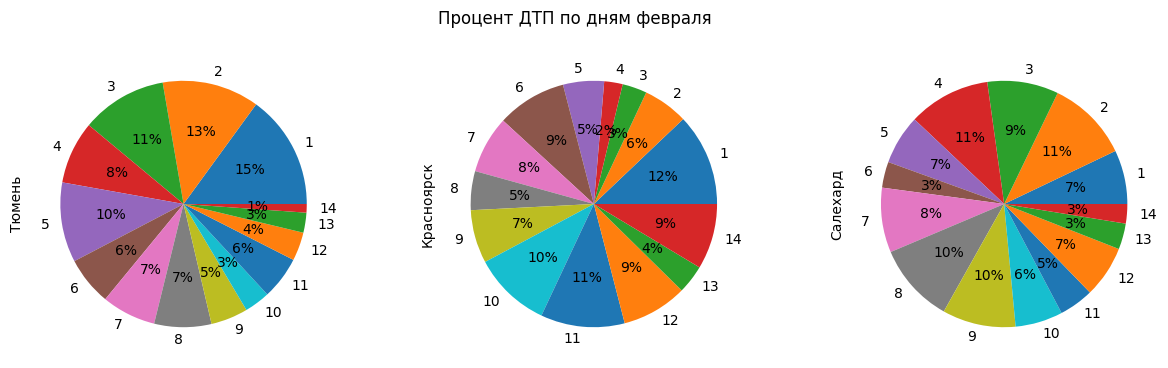

In [14]:
DTP.plot(kind = 'pie', figsize=(15, 4), autopct='%1.0f%%', title='Процент ДТП по дням февраля',
       subplots = True, legend = False) ;

Для сравнительного анализа уровня аварийности в разных городах может быть полезна круговая диграмма, где каждый сектор представляет не день месяца, а один из трёх городов.

Поскольку одна круговая диаграмма визуализирует одну серию данных, то для получения требуемого результата надо построить серию, где индексами будут не дни месяца, а названия городов. Для каждого города имеется 14 числовых значений, а для получения круговой диаграммы нужно только одно. Будем использовать общее число ДТП (по городам) за рассматриваемый период:

In [15]:
DTP.sum()

,0
Тюмень,267
Красноярск,372
Салехард,353


Метод **sum()** вернул нужную серию: индексами являются названия городов, значениями - суммарное число ДТП по городам, тип данных - целочисленный.

Не создавая для хранения этой серии отдельную переменную, просто визуализируем результат применения метода  **sum()** к фрейму **DTP** в виде круговой диаграммы; добавим заголовок и долю в процентах каждого города в общем объеме ДТП:

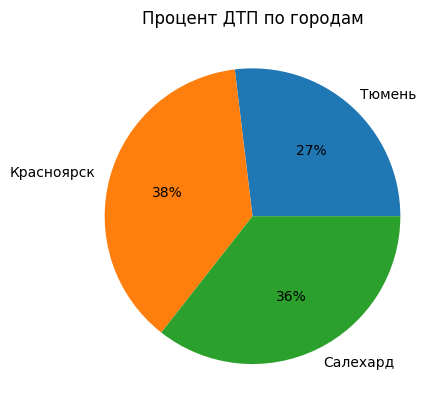

In [16]:
DTP.sum().plot.pie(title = 'Процент ДТП по городам', autopct='%1.0f%%');

### Столбиковая диаграмма BAR
  
Важно понимать: выбор типа диаграммы/графика ограничен типом визуализируемых данных.

Например, для демонстрации динамики температуры в г. Тюмени использовался линейный график. Этот выбор соответствует типу данных: значение температуры - величина непрерывная и вид графика (ломаная линия) хорошо представляет изменение непрерывной величины.

Количество ДТП в городах - величина дискретная, но линейный (непрерывный) график для демонстрации динамики тоже допустим, т.к. эти данные также представляют собой временной ряд, и по оси абцисс откладывается время - непрерывный признак (по факту в этом фрейме индекс может представлять непрерывную величину).
    
Рассмотрим другой игрушечный набор данных, представляющий площадь и численность населения некоторых европейских городов:

In [17]:
cities = {"name": ["London", "Berlin", "Madrid", "Rome",
                   "Paris", "Vienna", "Bucharest", "Hamburg",
                   "Budapest", "Warsaw", "Barcelona",
                   "Munich", "Milan"],
          "population": [8615246, 3562166, 3165235, 2874038,
                         2273305, 1805681, 1803425, 1760433,
                         1754000, 1740119, 1602386, 1493900,
                         1350680],
          "area" : [1572, 891.85, 605.77, 1285,
                    105.4, 414.6, 228, 755,
                    525.2, 517, 101.9, 310.4,
                    181.8]
}

city = pd.DataFrame(cities,
                          columns=["population", "area"],
                          index=cities["name"])
city


,population,area
London,8615246,1572.00
Berlin,3562166,891.85
Madrid,3165235,605.77
Rome,2874038,1285.00
Paris,2273305,105.40
Vienna,1805681,414.60
Bucharest,1803425,228.00
Hamburg,1760433,755.00
Budapest,1754000,525.20
Warsaw,1740119,517.00


Попытка представить эти данные в виде линейного графика приведёт к непонятному результату:

<Axes: >

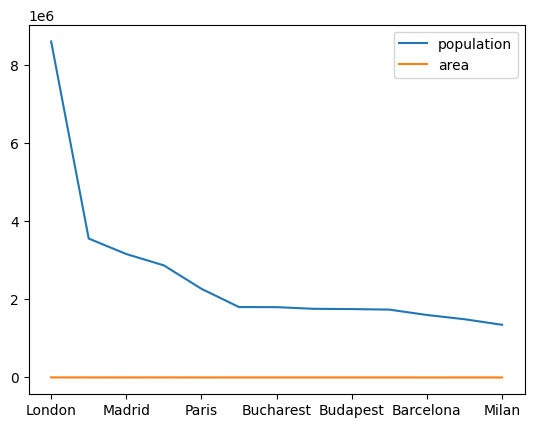

In [18]:
city.plot()

Что здесь плохо?
1. Куда-то пропала половина названий городов. Это можно "вылечить", указав в списке параметров перечень меток оси абсцисс:

<code>xticks=range(len(city_frame.index)), use_index=True</code>

Однако легко догадаться, что в результате названия городов будут накладываться друг на друга. Можно "вылечить" и это, повернув надписи меток на 90 градусов с помощью соответствующей настройки метода **plot()**:

<code>rot=90</code>

2. Подпись "1e6" над шкалой оси ординат означает, что значения отметок этой оси надо умножать на $10^6$ (на миллион), т.е. в Лондоне не 8, а более 8 млн жителей.  

3. Если верить графику, то площадь всех городов равна нулю, хотя на самом деле, это не так. Причина в разном масштабе значений серий: в абсолютных числах величина площади Лондона (1572 кв.км) в 5000 раз меньше числа его жителей (8615246 чел), поэтому максимальный подъём графика площади будет не выше 1 пикселя. Конечно, можно выровнять масштабы графиков, указывая население в тыс. человек (т.е. поделить исходные значения на 1000). Но и в этом случае остаётся неоднозначное толкование шкалы оси ординат графика.

В статистике существует подход, позволяющий привести разные шкалы к единому масштабу. Для этого одно из значений признака объявляют базой и делят на него все значения этого признака. В результате база становится равной 1 (100%), а другие значения заменяются на их отношение к этой базе. Фактически, абсолютные (размерные) значения превращаются в относительные (безразмерные).

Исправим все отмеченные моменты:

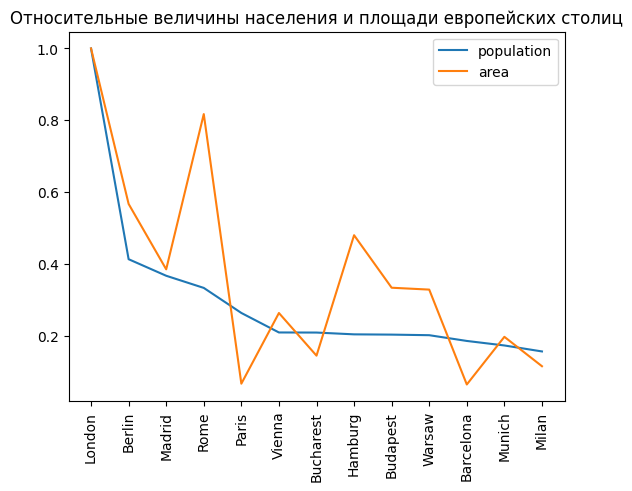

In [19]:
# приведение данных в относительные величины - относительно первой по порядку записи
city['area']=city['area']/city['area'].iloc[0]
city['population']=city['population']/city['population'].iloc[0]

# отрисовка графика
city.plot(xticks=range(len(city.index)), use_index=True, rot=90,
         title = 'Относительные величины населения и площади европейских столиц');


На первый взгляд, получилось неплохо. По графику видно, что площадь Мадрида составляет 40% от площади Лондона, а население Варшавы примерно в 2 раза меньше населения Берлина.

Однако, если верить графику, площадь европейских городов от Рима до Парижа резко и непрерывно падает, а население от Будапешта до Варшавы почти не меняется. Странно звучит и также странно выглядит.

Для визуализации данных с дискретными по своей природе индексами (в данном примере - названия городов) используют не непрерывные линейные графики, а дискретные столбиковые диаграммы (<code>kind='bar'</code>):

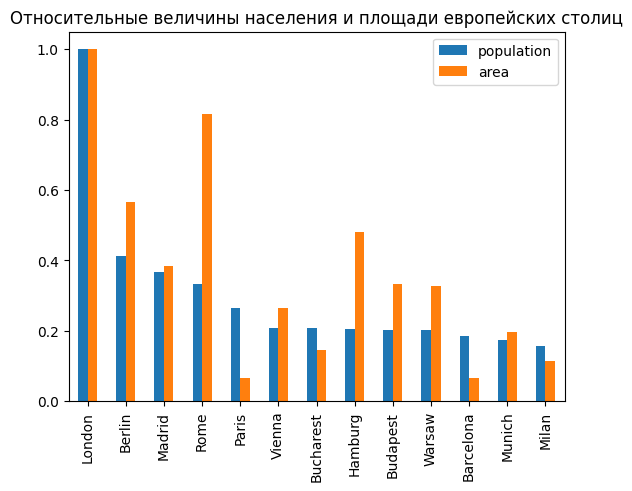

In [20]:
city.plot(kind='bar',  title = 'Относительные величины населения и площади европейских столиц');

Применим эти же настройки для построения столбиковой диаграммы по числу ДТП, оставив для визуализации данные только по первой неделе февраля.

Упражнение: найдите в коде, где указано, что нужно взять только первые 7 строк фрейма.

Обратите вимание: среди параметров есть <code>rot=0</code>. Если не использовать эту настройку, то будет применён угол поворота подписей по горизонтальной оси в 90 градусов, установленный ранее и действующий на следующие графики (до изменения настроек).

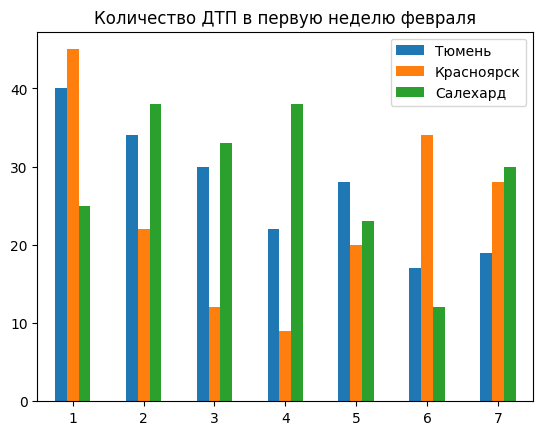

In [21]:
DTP[:7].plot(kind='bar', rot=0, title = 'Количество ДТП в первую неделю февраля');

При желании столбики на диаграмме можно накладывать друг на друга. Для  этого настроим ещё один параметр: <code>stacked=True</code>

Дополнительно изменим палитру цветов:

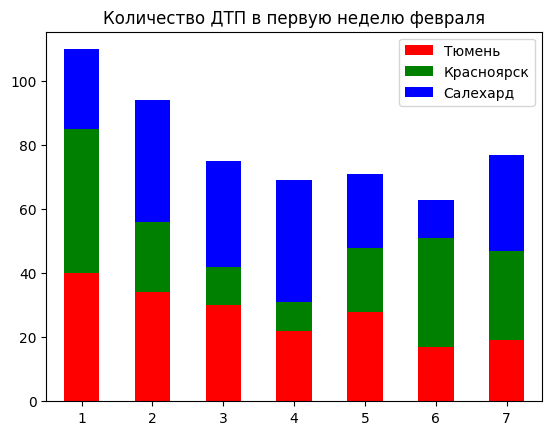

In [22]:
DTP[:7].plot(kind='bar', rot=0, title = 'Количество ДТП в первую неделю февраля',
             stacked=True, color = ['red', 'green','blue']);

### Горизонтальные полосы BARH

В некоторых случаях столбиковую диаграмму удобно транспонировать так, чтобы столбики отдельных объектов превратились в горизонтальные полосы.

Для построения такой горизонтальной диаграммы в Pandas используется значение 'barh' параметра **kind**:

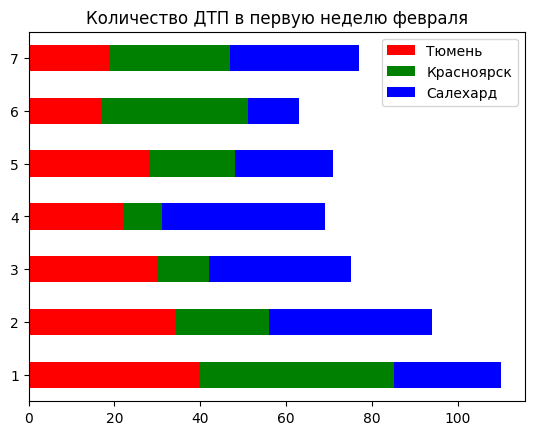

In [23]:
DTP[:7].plot(kind='barh', rot=0, title = 'Количество ДТП в первую неделю февраля',
             stacked=True, color = ['red', 'green','blue']);

Далее рассматриваются виды диаграмм, которые более интересны статистикам, чем простым созерцателям. И хотя элементы статистики мы ещё не изучали, знакомство с этими диаграммами не должно быть сложным для студентов 2-го курса.

## <center> Статистические диаграммы

### Немного о математической статистике

Как известно, математика - наука точная. Математическая статистика - это один из разделов математики. Поэтому она тоже является точной наукой. И это не юмор. Всем известна крылатая фраза (приписывается Марку Твену):  «Существуют три вида лжи: ложь, наглая ложь и статистика». А вот это одновременно и юмор и "наглая ложь".
    
Математическая статистика не ошибается. Ошибаться может человек, неправильно применяющий методы статистики в своих исследованиях. Суть в том, что статистика призвана на основе наблюдения только за частью элементов (выборкой) из некоторой большой (генеральной) совокупности объектов сделать вывод о всей совокупности. В том числе, о неизвестных наблюдателю элементах всей генеральной совокупности.  Например, математическая статистика позволяет на основе измерения роста студентов только 2-го курса ТюмГУ сделать суждение относительно среднего роста студентов всего университета (спрогнозировать, оценить, предположить). Допустим, изучив рост студентов 2-го курса, наблюдатель установил, что их средний рост равен 172.4 см. Можем ли мы на основании этих данных оценить (предсказать) средний рост студентов всего университета?
    
И нет и да.
    
**Нет** - потому, что в данной ситуации невозможно точно оценить средний рост студентов университета одним числом. Попытка перенести оценку параметра отдельной выборки на всю совокупность (т.е. заявить, что средний рост всех студентов университета также равен 172.4 см) практически всегда приводит к ошибке.
    
**Да** - потому, что грамотная статистическая оценка исследуемого параметра представляется неким интервалом и вероятностью, с которой реальная оценка окажется в этом интервале. Например, для нашей задачи о среднем росте студентов университета статистическая (предсказанная) оценка может быть вида "*с вероятностью 95% средний рост студентов всего университета окажется в диапазоне от 168.8 см до 176.0 см*". Границы диапазона есть полученная точечная оценка (172.4 см) плюс-минус статистическая погрешность (допустим, в нашем примере погрешность 3.6 см). Другими словами, если реальный средний рост студентов всего университета не попадёт в подсчитанный статистиками интервал, то такое может случиться лишь в 5% случаев.
    
    
Очевидно, что размер данного интервала (величина статистической погрешности) зависит от объёма генеральной совокупности, объема исследованной её части (выборки), от неоднородности данных внутри выборки, от характера распределения значений измеряемого параметра. Правильным учётом этих особенностей и занимается, в частности, математическая статистика, с которой вы познакомитесь позже, и которая является одним из инструментов анализа данных.  
    

### Гистограммы HIST

Одним из наглядных средств визуализиции характера распределения значений некоторого признака для группы объектов (выборки) является гистограмма.
    
Рассмотрим данные (возраст, рост и вес) группы людей, загруженные из файла 'AHW.csv', который имеется в ресурсах данного занятия в системе LMS.

In [24]:
df=pd.read_csv('AHW.csv')
df

,Age,Height,Weight
0,61,1.85,109.30
1,60,1.71,79.02
2,60,1.55,74.70
3,60,1.46,35.90
4,60,1.58,97.10
...,...,...,...
736,34,1.86,95.70
737,44,1.91,106.90
738,25,1.82,88.40
739,35,1.88,98.50


Загружены данные 741 человека. Их признаки возраст, рост и вес представлены в столбцах 'Age','Height','Weight' соответственно.
Попробуем просто построить линейный график по этим данным:

<Axes: >

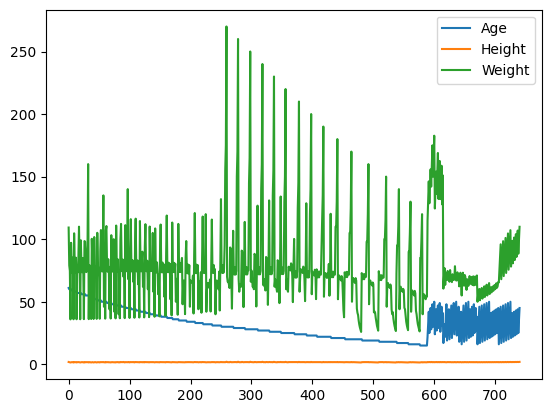

In [25]:
df.plot()

Получилось что-то непонятное.

Возможно, более информативной окажется гистограмма данных:

<Axes: ylabel='Frequency'>

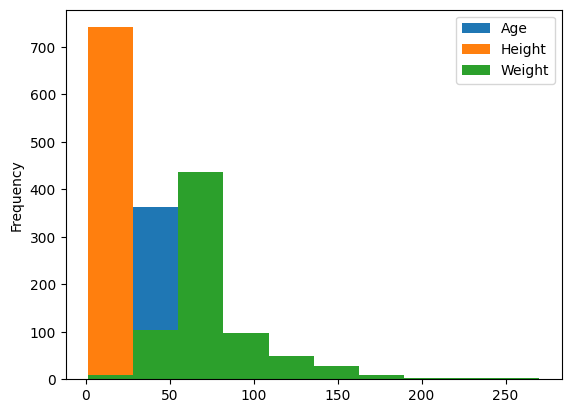

In [26]:
df.plot.hist()

В целом понятнее не стало. Но попробуем рассмотреть гистограмму отдельного признака, например, возраста:

<Axes: title={'center': 'Гистограмма возраста'}, ylabel='Frequency'>

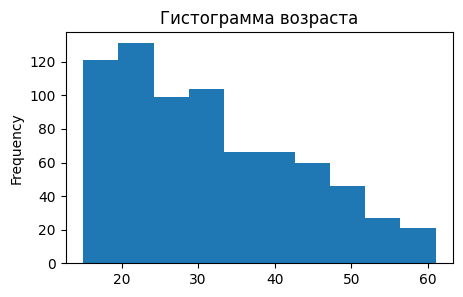

In [27]:
df['Age'].plot.hist(title='Гистограмма возраста', figsize = (5,3))

На горизонтальной оси гистограммы расположены значения исследуемого признака (в данном случае возраста).

Видно, что минимальный возраст примерно 15 лет, а максимальный - 61 год. Весь диапазон [15, 61] разбит на 10 равных по длине интервалов (бинов). Сами интервалы не показаны, но видны столбики над каждым из бинов (10 столбиков разной высоты). Высота каждого столбика пропорциональна числу объектов выборки, для которых значение возраста попало в соответствующий интервал. Это число объектов для каждого интервала можно увидеть на шкале вертикальной оси. Так, в первый интервал (примерно от 15 до 20 лет) попали 120 человек из 741. Во второй (примерно от 21 до 25 лет) попали 130 человек. Это самый большой по числу объектов бин. Самым маленьким оказался последний 10-й бин (от 56 до 61 года). Там примерно 25 человек. Таким образом, видно, что по возрасту выборка распределена неравномерно: основную её часть составляют молодые люди до 33 лет.

Сформируем не 10, а 25 бинов:

<Axes: title={'center': 'Гистограмма возраста'}, ylabel='Frequency'>

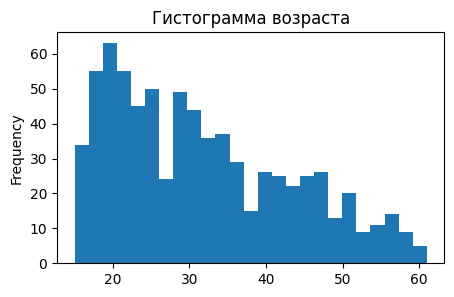

In [28]:
df['Age'].plot.hist(title='Гистограмма возраста', figsize = (5,3), bins=25)

Интервалы стали короче (примерно, по два года), в каждом из них стало меньше объектов (людей). Несмотря на заметные провалы для 27-летних и 39-летних, видна общая тенденция к линейному уменьшению числа людей с увеличением возраста.

Сформируем 100 бинов и осмыслим результат:

<Axes: title={'center': 'Гистограмма возраста'}, ylabel='Frequency'>

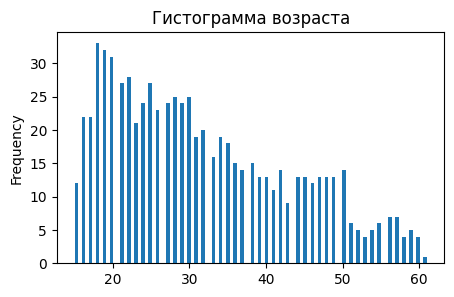

In [29]:
df['Age'].plot.hist(title='Гистограмма возраста', figsize = (5,3), bins=100)

Т.к. интервалов всего 100, то длина каждого (61-15)/100 = 0.46 года, и поэтому только некоторые из них содержат целое значение возраста. А высота столбиков для этих бинов - это число людей такого возраста.

Посмотрим гистораммы роста и веса (укажем для каждой по 20 бинов)

<Axes: title={'center': 'Гистограмма роста'}, ylabel='Frequency'>

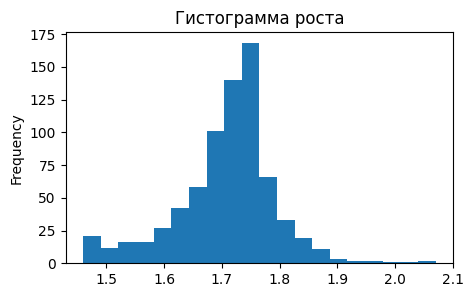

In [30]:
df['Height'].plot.hist(title='Гистограмма роста', figsize = (5,3), bins=20)

<Axes: title={'center': 'Гистограмма веса'}, ylabel='Frequency'>

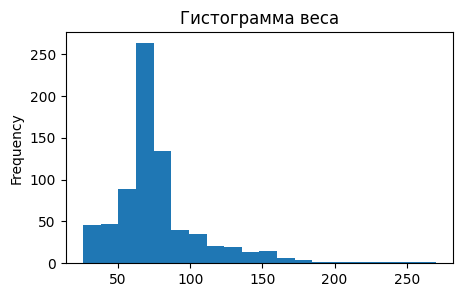

In [31]:
df['Weight'].plot.hist(title='Гистограмма веса', figsize = (5,3), bins=20)

Здесь другая картина распределения. Наибольшими являются средние бины, а чем ближе к крайним интервалам, тем число объектов в них становится меньше, и падает прочти до нуля. Такое распределение принято называть близким к нормальному. Видно, что наиболее часто встречающимся ростом является примерно 174 см, а наиболее частым весом примерно 70 кг. По гистограмме веса видно, что есть небольшое число людей весом 200, 250 килограммов и даже более.

Иногда для сравнения удобно, чтобы все гистограммы отображались на одном графике. В рассматриваемом примере это затруднительно, поскольку шкалы признаков имеют разные масштабы.

Такая ситуация уже рассматривалась в примере для столбиковой диаграммы; тогда проблема была решена путем перехода от абсолютных к относительным величинам делением на базовое значение. В данном случае будем использовать другой способ перехода к относительным значениям:  для каждого признака приведём исходный диапазон [min, max] к диапазону [0, 1]. В результате минимальные значения будут заменены нулём, максимальные - единицей, а промежуточные - пропорционально между 0 и 1. Такой подход называется **min-max нормализацией** (будет рассмотрена в одной следующих тем курса):  

<Axes: title={'center': 'Гистограмм'}, ylabel='Frequency'>

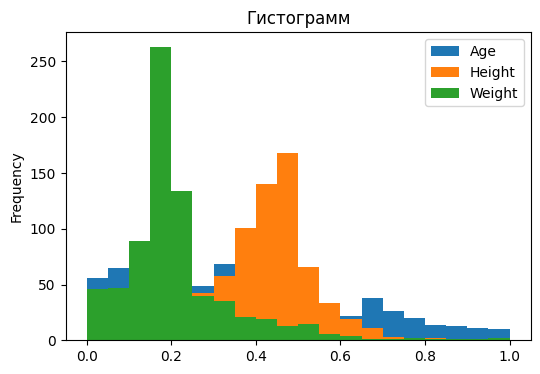

In [32]:
n_df=(df-df.min())/(df.max()-df.min())
n_df.plot.hist(title='Гистограмм', figsize = (6,4), bins=20)

Гистограммы для разных признаков отрисовываются по очереди, поэтому диаграмма, отрисованная последней (зеленая), частично заслоняет предыдущие.

Настроим заливку столбиков полупрозрачной:

<Axes: title={'center': 'Гистограмм'}, ylabel='Frequency'>

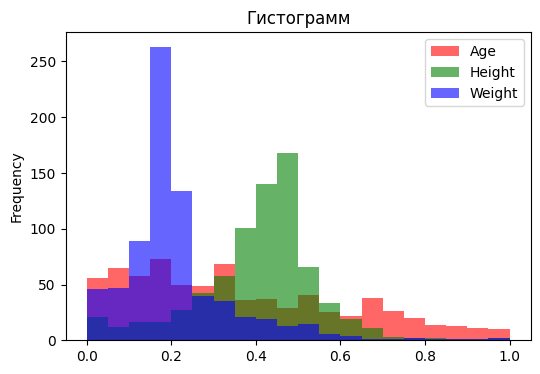

In [33]:
n_df.plot.hist(title='Гистограмм', figsize = (6,4), bins=20, alpha = 0.6,
              color=['red','green','blue'])


### Диаграмма рассеяния SCATTER

Для визуальной оценки зависимости между разными признаками часто применяют диаграмму рассеяния.
    

<Axes: xlabel='Height', ylabel='Weight'>

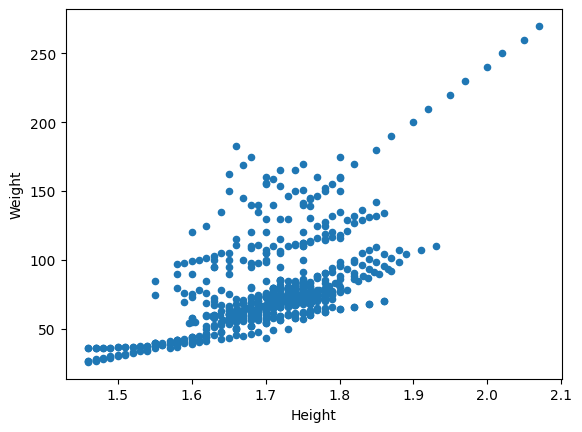

In [34]:
df.plot.scatter(x='Height',y='Weight')

На этой диаграмме каждый объект, признаки которого соответствуют отдельной строке фрейма данных, отображается в виде точки, координатами которой являются значения признаков, указанных в методе <code>plot()</code> как X и Y. В рассматриваемом примере в качестве x-координаты указан рост человека, а в качестве y-координаты - его вес.

Рассматривая данную диаграмму можно увидеть, что с увеличением роста вес человека также увеличивается, но далеко не всегда эта зависимость однозначна. Видно, что имеется многочисленная группа людей (на диаграмме вытянутое нижнее облачко), для которых эта тенденция почти линейна. Внимательный исследователь заметит, что можно выделить группы точек, почти идеально расположенных на строгих прямых линиях. Например, очень странно выглядит линия точек, идущая от цента диаграммы в правый верхний угол. Похоже, эти точки представляют собой 15 человек, у которых рост равномерно возрастает от 170 до 210 см и вес также равномерно увеличивается от 130 до 270 кг по линейному закону относительно роста. Случайно такого не бывает. Это свидетельствует о том, что данный набор тоже игрушечный, он состоит из нескольких поднаборов, часть из которых сгенерирована программно по разным формулам. Для реальных данных (случайная выборка) рассеяние точек на диаграмме выглядело бы не столь регулярным.

Обычно на координатной плоскости, которая является подложкой для диаграммы рассеяния, можно отобразить лишь два признака объекта - X и Y - координаты точки, его представляющей. Но SCATTER позволяет показать три, и даже 4 признака.

Отобразим третий признак человека - его возраст ('Age') - в виде размера точек:

<Axes: xlabel='Height', ylabel='Weight'>

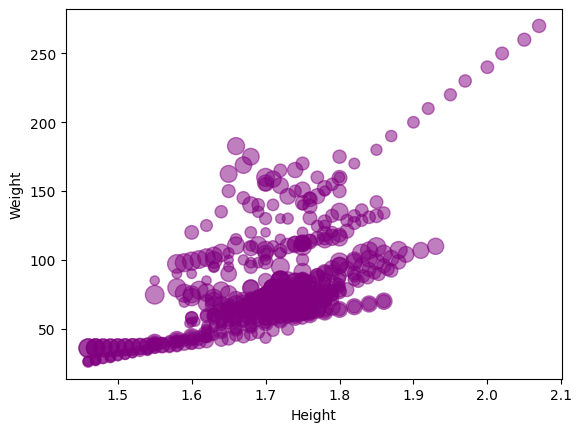

In [35]:
df.plot.scatter(x='Height',y='Weight', s = df['Age'] * 3,
                          alpha=0.5, c='purple')

Можно заметить, что некоторые точки больше других (свойство **s** - size). Они соответствуют людям более старшего возраста.

Четвертого параметра в этом наборе данных нет, но для иллюстрации мы можем взять индекс массы тела (ИМТ или BMI - body mass index) - отношение массы человека в килограммах к квадрату его роста в метрах. Настроим диаграмму так, чтобы значение ИМТ влияло на цвет отдельной точки (параметр **c** - color):

<Axes: xlabel='Height', ylabel='Weight'>

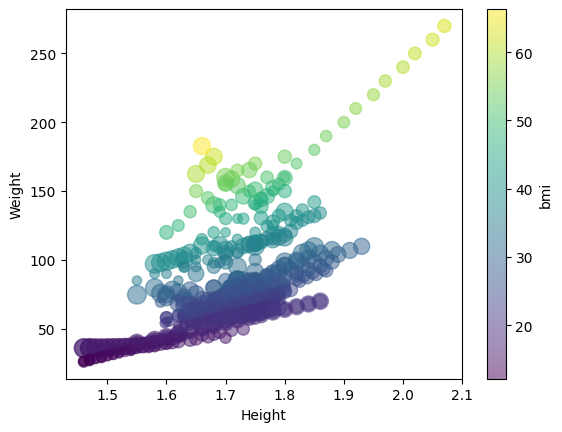

In [36]:
df['bmi']=df['Weight']/(df['Height']*df['Height'])             # формирование признака ИМТ (BMI)
df.plot.scatter(x='Height',y='Weight', s = df['Age'] * 3,
                          alpha=0.5, c='bmi')

### Диаграмма рассеяния HEXBIN

Это аналог диаграммы SCATTER, где точки имеют шестиугольную форму. В каком-то смысле это и аналог гистограммы, потому, что объекты разбиваются на бины. Только в гистограмме бины одномерные - это интервалы на прямой, а здесь бины двумерные - это небольшие правильные шестиугольники, плотно заполняющие область графика, что очень похоже на пчелиные соты. Цвет каждой ячейки зависит от числа точек, попавших в неё: чем больше точек, тем цвет интенсивнее. Если одномерный бин представляет один признак, то двумерный - два (в нашем примере это **X** и **Y** - рост и вес человека).
    
Посмотрим, как выглядит такая диаграмма в самом простом случае:    

<Axes: xlabel='Height', ylabel='Weight'>

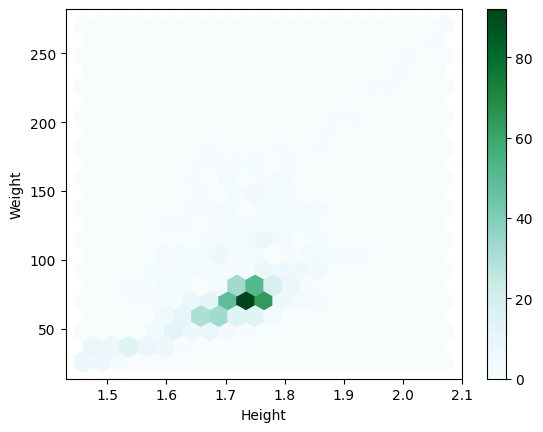

In [37]:
df.plot.hexbin(x='Height', y='Weight', gridsize= 20)

Здесь более темный цвет представляет более высокую плотность данных, а более светлый цвет представляет низкую плотность данных. В отличие от гистограммы, число объектов отдельного бина представлено не высотой полосок, а интенсивностью цвета. Как видим, в рассматриваемом наборе наиболее частой парой значений (рост, вес) является пара примерно (173, 70). Соответствующий бин самый тёмный на диаграмме.

Если мы добавим дополнительный параметр «C», распределение изменится. Параметр «C» определяет, какой признак объекта отвечает за цвет ячейки, а вспомогательный параметр "reduce_C_function" уточняет, какое значение признака будет отображаться, если в ячейке окажутся несколько объектов. В примере ниже выбрано <code>C='Age', reduce_C_function=np.average</code>, значит цвет ячейки указывает на средний возраст людей с данными ростом и весом.

<Axes: xlabel='Height', ylabel='Weight'>

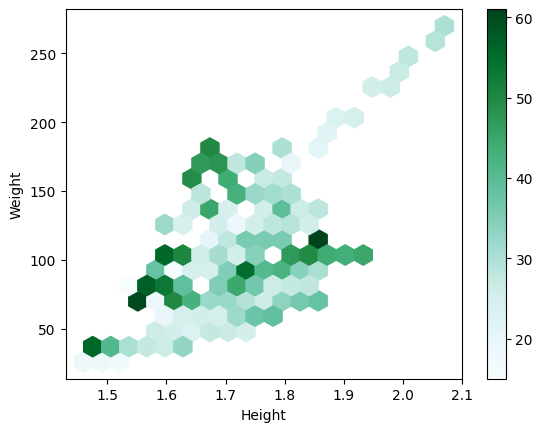

In [38]:
df.plot.hexbin(x='Height', y='Weight', C='Age', gridsize= 20, reduce_C_function=np.average)

### Другие виды диаграмм в Pandas

В рамках этого занятия мы не будем рассматривать диаграммы вида KDE (функция распределения) и BOX (boxplot, ящичная диаграмма, ящик с усами), т.к. они требуют более серьёзных знаний в области математической статистики. Ящичные диаграммы будут рассмотрены в одной из следующих тем курса.

Но ничто не мешает и на этом занятии просто построить примеры некоторых других диаграмм по рассмотренным датасетам (фреймам). Можно руководствоваться документацией библиотеки, подумать, спросить у преподавателя...

Кроме рассмотренных выше, в Pandas есть и другие средства графической визуализиции, собранные в подбиблиотеке **pandas.plotting**.

Например: SCATTER_MATRIX.

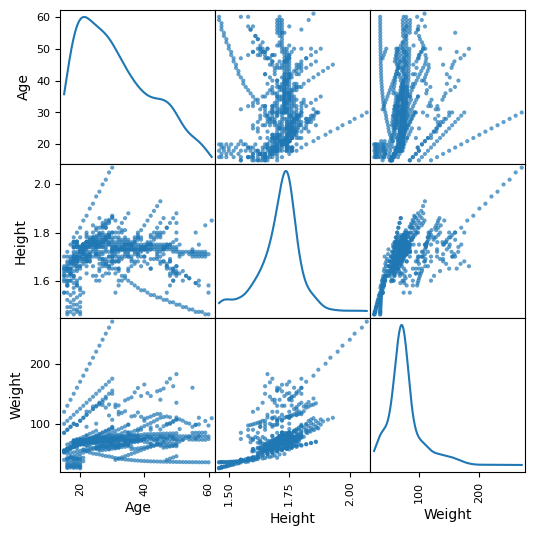

In [39]:
from pandas.plotting import scatter_matrix
scatter_matrix(df[['Age', 'Height', 'Weight']],
                                           alpha = 0.7, figsize=(6, 6), diagonal = 'kde');

Это так называемая матрица диаграмм рассеяния. Строки и столбцы матрицы подписаны названиями признаков объекта. Ячейки на их пересечении представляют диаграмму рассеяния по соответствующим признакам. Одна из них (Height-Weigh) уже была построена ранее с помощью метода "scatter".

По главной диагонали матрицы (где признаки строки и столбца совпадают) показан KDE - график плотности распределения (непрерывный аналог гистограммы).  

## <center>Продвинутая визуализация данных на Python

Использовать для визуализации возможности библиотеки Pandas - это необходимый минимум для работы с данными. Для Pandas визуализация данных - вспомогательный функционал. Существует много библиотек, которые специализируются именно на визуализации данных.

Вот некторые из них:
- **Matplotlib** - обладает богатыми возможностями для построения графиков разного типа и сложности. Но настройка этих возможностей потребует от пользователя много кода.
- **Seaborn** - эта библиотека построена на базе Matplotlib. Она более высокоуровневая, что упрощает ее использование. Несмотря на то, что коллекция графиков не настолько большая, как в Matplotlib, созданные с помощью seaborn широко используемые графики при меньшем количестве кода будет выглядеть визуально приятнее.
- **Plotly** - упрощает создание интерактивных графиков типографского качества. При этом она также может создавать классические диаграммы хорошего качества буквально за несколько строчек кода.
- **Altair** - эта библиотека визуализации, предназначенная для построения графиков, требующих большого количества статистических преобразований. Altair не может обрабатывать данные, превышающие 5000 экземпляров, и некоторые простые диаграммы в нем уступают по стилю Plotly или Seaborn.
- **Bokeh** - интерактивная библиотека для визуализации, предназначенная для презентации данных в браузерах.
- **Folium** - позволяет легко визуализировать данные на интерактивной встраиваемой карте. Несмотря на то, что Plotly, Altair и Bokeh также позволяют создавать карты, Folium использует открытую уличную карту, близкую к Google Map, с помощью минимального количества кода.


Для построения традиционных диаграмм достаточно знать **Pandas**. Если требуется тонкая настройка диаграмм, то используется **Matplotlib** или **Seaborn**.

На [официальном сайте Matplotlib](https://matplotlib.org/stable/tutorials/index.html) имеется несколько несколько руководств по её использованию с загружаемыми примерами как просто кода так и учебных блокнотов **.jpynb**.

Существует [сетевой учебник](https://devpractice.ru/files/books/python/Matplotlib.book.pdf) по **Matplotlib** (на русском языке).

По запросу любой поисковик найдет десятки руководств по визуализации данных в Python разной степени полноты и солидности.